# Training Metrics Review
This notebook groups the metrics saved by `MetricsStorage` and `validate` so we can quickly spot obvious issues.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.notebooks.review_utils import (
    PROJECT_ROOT,
    list_metric_files,
    load_metrics,
    metrics_to_frame,
    plot_metric_groups,
    plot_run_comparison,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 120)
PROJECT_ROOT

WindowsPath('C:/Users/ulloa/Miooooo/Master/thesis/projectes/From-Noisy-Eye-Tracking-To-Scanpath')

In [2]:
metric_files = list_metric_files()
display(metric_files.head(20))

,run_dir,metrics_file,modified,size_kb
0,outputs\outputs\2026-03-10\17-31-04,outputs\outputs\2026-03-10\17-31-04\metrics.json,2026-03-16 14:59:37.419492960,2.5
1,outputs\outputs\2026-03-12\10-44-15,outputs\outputs\2026-03-12\10-44-15\metrics.json,2026-03-16 14:59:32.252549886,6.4
2,outputs\outputs\2026-03-12\14-25-24,outputs\outputs\2026-03-12\14-25-24\metrics.json,2026-03-16 14:59:26.283334970,21.4
3,outputs\outputs\2026-03-16\15-45-44,outputs\outputs\2026-03-16\15-45-44\metrics.json,2026-03-16 14:59:26.008493662,1.2
4,outputs\outputs\2026-03-16\15-32-24,outputs\outputs\2026-03-16\15-32-24\metrics.json,2026-03-16 14:59:17.745660782,0.5


In [3]:
selected_metrics_path = None
if not metric_files.empty:
    selected_metrics_path = PROJECT_ROOT / metric_files.iloc[0]['metrics_file']
selected_metrics_path

WindowsPath('C:/Users/ulloa/Miooooo/Master/thesis/projectes/From-Noisy-Eye-Tracking-To-Scanpath/outputs/outputs/2026-03-10/17-31-04/metrics.json')

In [4]:
if selected_metrics_path is not None:
    metrics = load_metrics(selected_metrics_path)
    metric_frame = metrics_to_frame(metrics)
    display(metric_frame.head(20))
    display(metric_frame.groupby('metric')['value'].agg(['count', 'min', 'max', 'mean']).sort_index())

,metric,epoch,value
0,reg_error_val,5,72.119187
1,reg_error_val,10,71.207955
2,duration_error_val,5,92.105640
3,duration_error_val,10,93.133597
4,outliers_count_val,5,0.000000
5,outliers_count_val,10,0.000000
6,accuracy,5,0.867790
7,accuracy,10,0.866347
8,precision_pos,5,0.470961
9,precision_pos,10,0.463415


,count,min,max,mean
metric,,,,
accuracy,2,0.866347,0.867790,0.867068
cls_loss_train,10,0.041872,0.091504,0.050817
cls_loss_val,2,0.141206,0.172106,0.156656
coord_error_train,10,54.411906,88.355049,61.627221
coord_loss_train,10,0.080547,0.131064,0.091138
coord_loss_val,2,0.105045,0.106845,0.105945
denoise_error_train,10,49.078599,69.291987,53.126010
denoise_error_val,2,45.924494,47.644526,46.784510
denoise_loss_train,10,0.073266,0.102695,0.079051


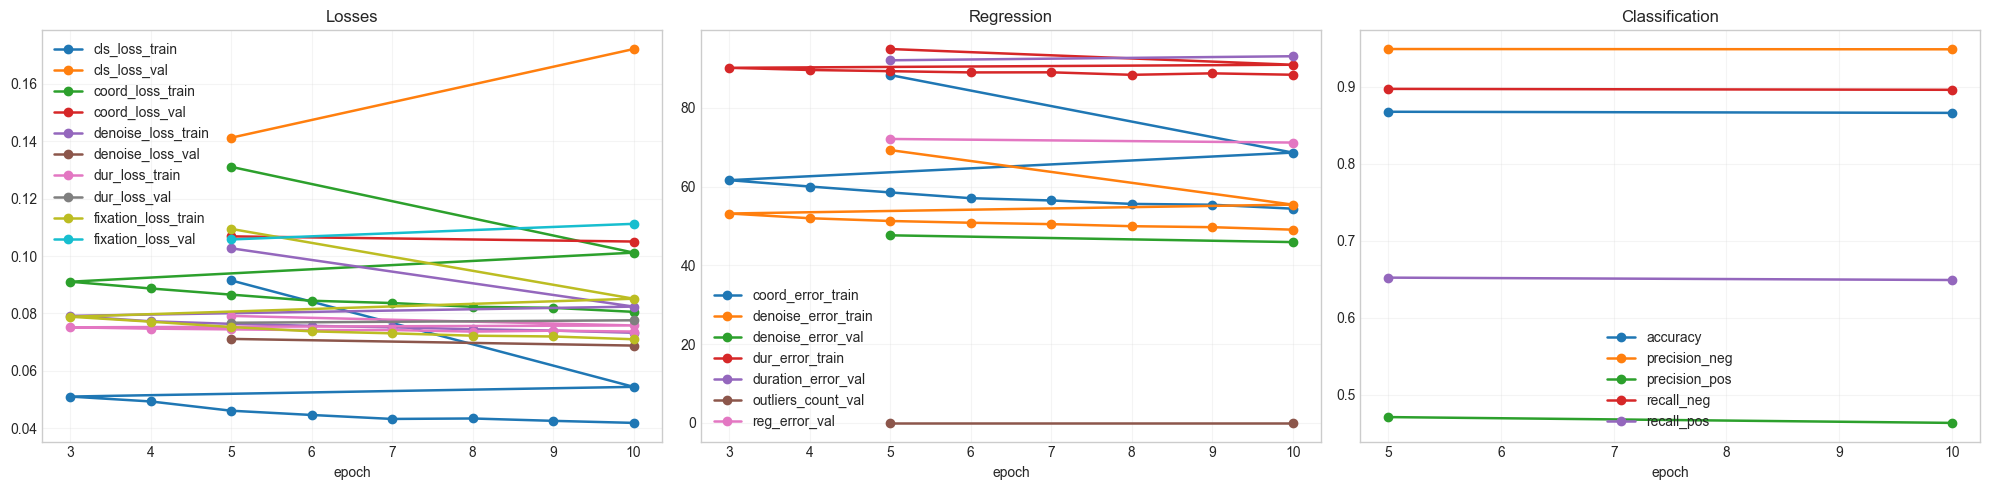

In [5]:
if selected_metrics_path is not None:
    plot_metric_groups(metrics)

In [6]:
if selected_metrics_path is not None:
    epoch_series = metrics.get('epoch', [])
    for metric_name in ['reg_loss_train', 'reg_loss_val', 'cls_loss_train', 'cls_loss_val', 'reg_error_val', 'accuracy']:
        if metric_name in metrics:
            print(metric_name, 'points=', len(metrics[metric_name]), 'epochs=', epoch_series[:len(metrics[metric_name])])

cls_loss_train points= 10 epochs= [5, 10]
cls_loss_val points= 2 epochs= [5, 10]
reg_error_val points= 2 epochs= [5, 10]
accuracy points= 2 epochs= [5, 10]


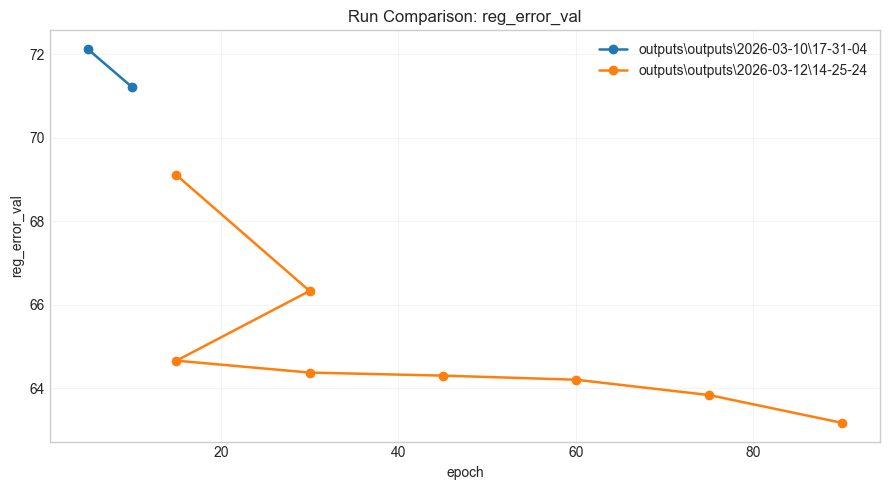

In [7]:
comparison_candidates = [PROJECT_ROOT / path for path in metric_files.head(3)['metrics_file'].tolist()]
if comparison_candidates:
    plot_run_comparison(comparison_candidates, metric_name='reg_error_val')

## Notes
- Validation metrics are appended only on validation epochs, so many training series are denser than validation series.
- `outliers_count_val` is stored as a total count over the whole validation pass, while most others are averaged by batch.
- This notebook is aimed at sanity-checking trends first, not at final reporting.